In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as cp
from scipy.interpolate import griddata
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from scipy.interpolate import interp1d
from TDECalculator import TDECalculator

plt.style.use("plot_style.mplstyle")
plt.rc('text', usetex=True)

In [2]:
def energy_plots(whole_star_sample): 
    # unpack
    dE_rand   = whole_star_sample['dEnergy_random']      # shape (nr-1, N_Omega)
    dE_unp    = whole_star_sample['dEnergy_unperturbed']
    dT_rand   = whole_star_sample['dT_random']
    dT_unp    = whole_star_sample['dT_unperturbed']
    dMass     = whole_star_sample['dMass']               # same shape

    # set up figure
    fig, (axE, axT) = plt.subplots(1, 2, figsize=(12,5))

    # histograms in E
    bins_E = np.linspace(-2, 2, 200)
    axE.hist(dE_rand.flatten(),
            weights=dMass.flatten(),
            bins=bins_E,
            density=True,
            alpha=0.5)
    axE.set_yscale('log')
    axE.set_xlabel(r'$ E / \Delta E$')
    axE.set_ylabel(r'$(\mathrm{d}M/\mathrm{d}E) / (M_\star / \Delta E)$')

    # histograms in T
    bins_T = np.logspace(0, 6, 200)
    axT.hist(dT_rand.flatten(),
            weights=dMass.flatten(),
            bins=bins_T,
            density=True,
            alpha=0.5)
    # overplot T^{-5/3} reference
    axT.plot(bins_T, 10*bins_T**(-5/3), 'k--', label=r'$T^{-5/3}$')
    axT.set_xscale('log')
    axT.set_yscale('log')
    axT.set_xlabel(r'$T / \Delta T$')
    axT.set_ylabel(r'$(\mathrm{d}M/\mathrm{d}T) / (M_\star / \Delta T)$')

    plt.tight_layout()
    plt.show()

In [3]:
mass = 'MAMS1Msun'
Mbh = 1e6
Rp = 18.0
a = 0.1
n = 1000

In [4]:
# calc = TDECalculator(mass, 'rel', Mbh, Rp, a, n)
calc_n = TDECalculator(mass, 'nwtn', Mbh, Rp, 0.0, n)
calc_s = TDECalculator(mass, 'rel', Mbh, Rp, 0.0, n)
# calc2 = TDECalculator(mass, 'rel', Mbh, Rp, -a, n)

In [5]:
whole_star_sample1 = calc.rel_whole_star_sample(N_Omega=300**2)

In [6]:
whole_star_sample2 = calc2.rel_whole_star_sample(N_Omega=300**2)

In [5]:
whole_star_sample_s = calc_s.rel_whole_star_sample(N_Omega=300**2)

In [6]:
whole_star_sample_n = calc_n.whole_star_sample(N_Omega=300**2)

In [12]:
np.std(whole_star_sample_s['y_pos'])

0.6840752240986803

In [13]:
np.std(whole_star_sample_n['y_pos'])

0.658536451657627

In [8]:
whole_star_sample_s['dEnergy_random'] 

array([[-7.44395149e-07,  3.67183055e-07, -5.30144105e-07, ...,
         6.55669546e-07, -7.02591424e-07,  8.24918181e-08],
       [-1.85434928e-06,  9.13655237e-07, -1.31802133e-06, ...,
         1.63286286e-06, -1.74953438e-06,  2.04754260e-07],
       [-2.57756745e-06,  1.26712046e-06, -1.82477157e-06, ...,
         2.26840344e-06, -2.42997846e-06,  2.82544825e-07],
       ...,
       [-1.72998813e-04, -3.53833440e-05, -1.02684463e-04, ...,
         9.63851176e-05, -1.47752921e-04,  4.96655787e-06],
       [-1.73017259e-04, -3.53930791e-05, -1.02703752e-04, ...,
         9.63931686e-05, -1.47769613e-04,  4.96853656e-06],
       [-1.73022232e-04, -3.53941060e-05, -1.02709429e-04, ...,
         9.63961157e-05, -1.47774370e-04,  4.96931290e-06]])

In [9]:
whole_star_sample_n['dEnergy_random'] 

array([[-9.49208965e-04, -1.03474497e-03, -7.08189686e-04, ...,
        -4.41971516e-04,  4.03181621e-04, -4.22563307e-04],
       [-2.36901973e-03, -2.58185772e-03, -1.76221743e-03, ...,
        -1.09691612e-03,  1.00652220e-03, -1.05039123e-03],
       [-3.30553110e-03, -3.60090516e-03, -2.44436691e-03, ...,
        -1.51374230e-03,  1.40516806e-03, -1.45427307e-03],
       ...,
       [-1.29958845e+00, -6.73917914e-01, -7.18616194e-01, ...,
        -4.11086132e-01,  1.23195289e+00, -9.87413059e-02],
       [-1.29965955e+00, -6.73903691e-01, -7.18646943e-01, ...,
        -4.11103821e-01,  1.23208815e+00, -9.87433371e-02],
       [-1.29968128e+00, -6.73905758e-01, -7.18661186e-01, ...,
        -4.11114932e-01,  1.23212605e+00, -9.87432603e-02]])

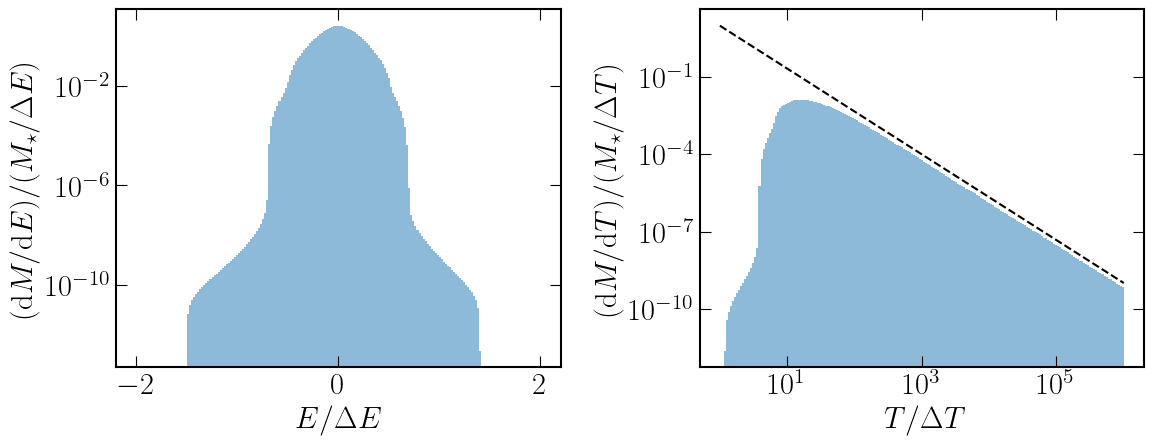

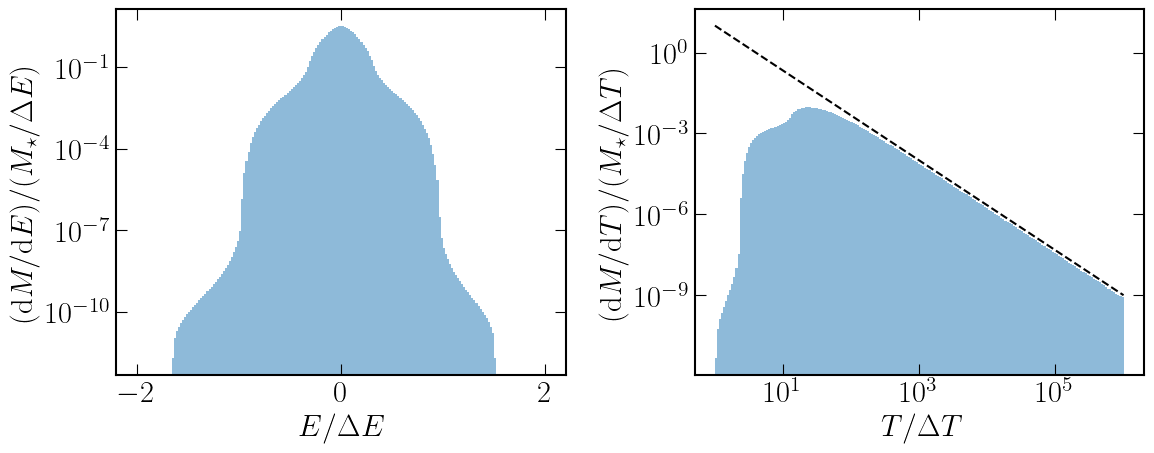

In [7]:
# energy_plots(whole_star_sample1)
# energy_plots(whole_star_sample2)
energy_plots(whole_star_sample_s)
energy_plots(whole_star_sample_n)

In [12]:
mass = 'MAMS2Msun'
Mbh = 1e6
Rp = 18
a = 0.5
n = 1000

In [13]:
calc = TDECalculator(mass, 'rel', Mbh, Rp, a, n)
calc_n = TDECalculator(mass, 'nwtn', Mbh, Rp, 0.0, n)
calc_s = TDECalculator(mass, 'rel', Mbh, Rp, 0.0, n)
calc2 = TDECalculator(mass, 'rel', Mbh, Rp, -a, n)

In [ ]:
whole_star_sample1 = calc.rel_whole_star_sample(N_Omega=300**2)

In [ ]:
whole_star_sample2 = calc2.rel_whole_star_sample(N_Omega=300**2)

In [ ]:
whole_star_sample_s = calc_s.rel_whole_star_sample(N_Omega=300**2)

In [ ]:
whole_star_sample_n = calc_n.whole_star_sample(N_Omega=300**2)

ordering: prograde, retrograde, schwartzschild, newtonian

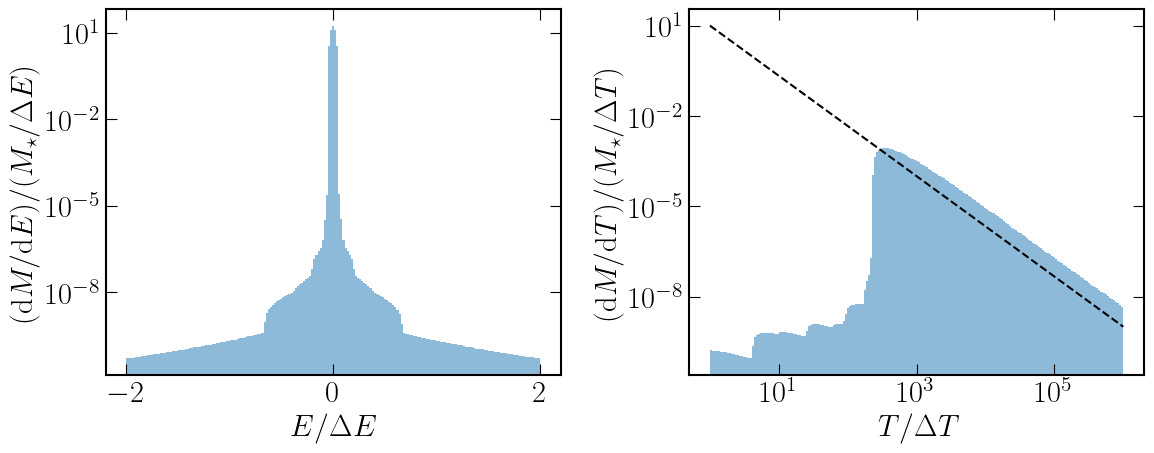

In [ ]:
energy_plots(whole_star_sample1)

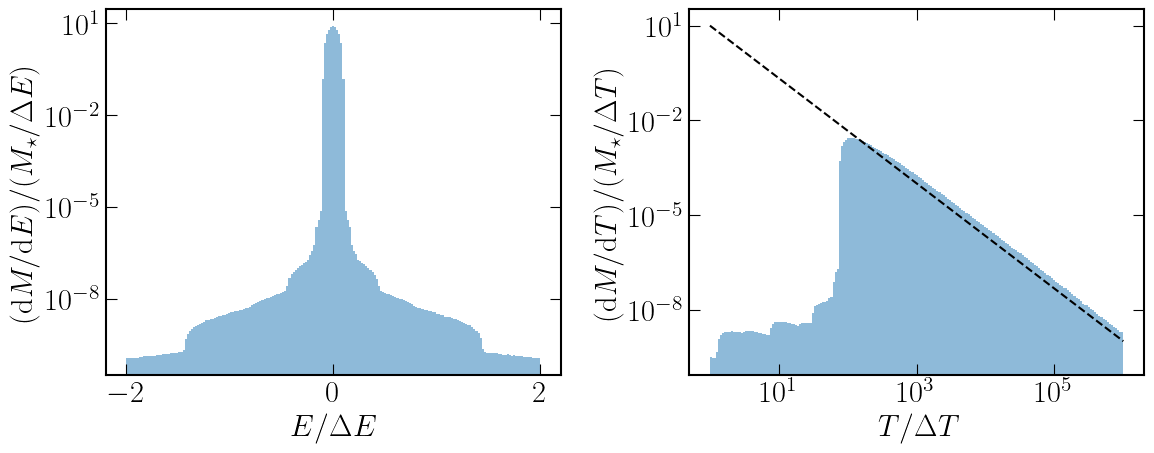

In [ ]:
energy_plots(whole_star_sample2)

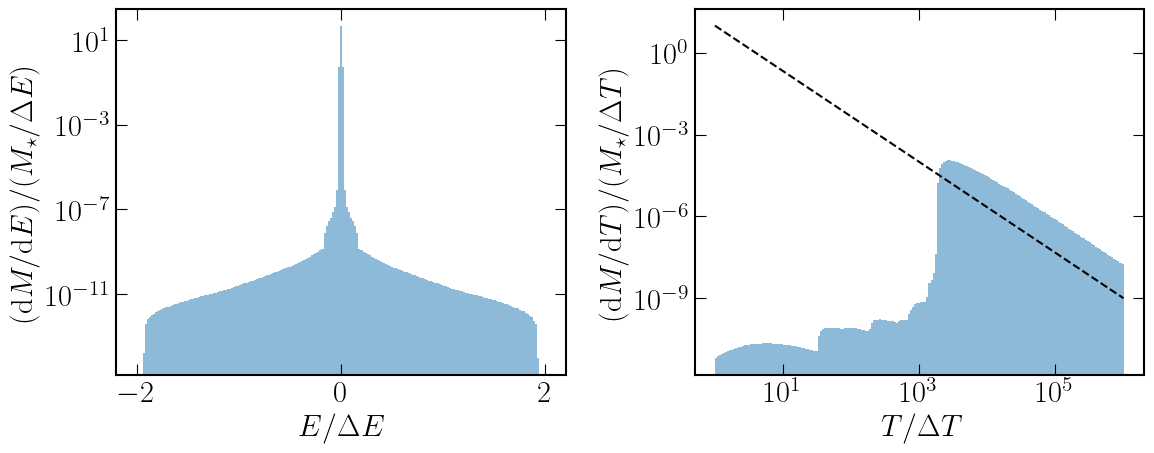

In [ ]:
energy_plots(whole_star_sample_s)

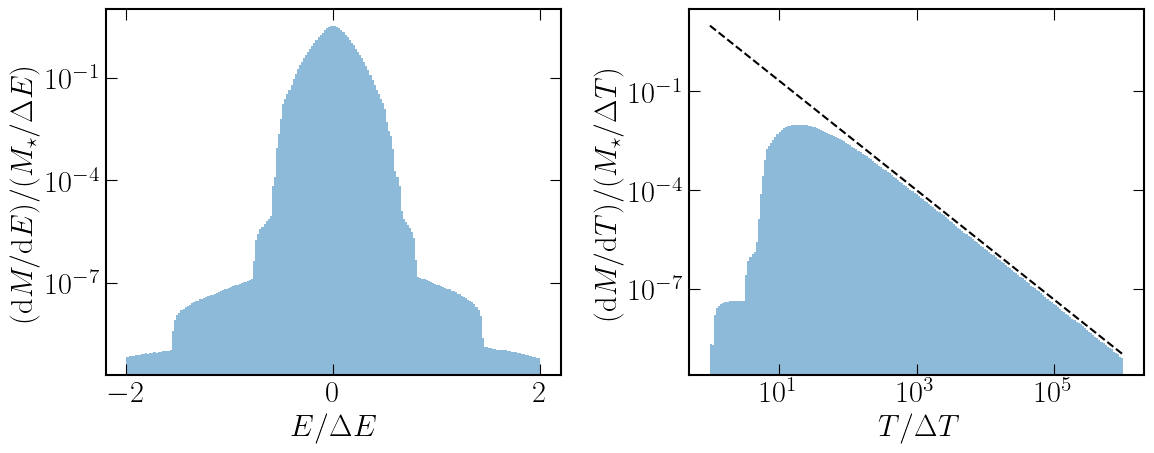

In [ ]:
energy_plots(whole_star_sample_n)

In [ ]:
mass = 'MAMS0p3Msun'
Mbh = 1e6
Rp = 8
a = 0.9
n = 1000

In [ ]:
calc = TDECalculator(mass, 'rel', Mbh, Rp, a, n)
calc_n = TDECalculator(mass, 'nwtn', Mbh, Rp, 0.0, n)
calc_s = TDECalculator(mass, 'rel', Mbh, Rp, 0.0, n)
calc2 = TDECalculator(mass, 'rel', Mbh, Rp, -a, n)

In [ ]:
whole_star_sample1 = calc.rel_whole_star_sample(N_Omega=300**2)
whole_star_sample2 = calc2.rel_whole_star_sample(N_Omega=300**2)
whole_star_sample_s = calc_s.rel_whole_star_sample(N_Omega=300**2)
whole_star_sample_n = calc_n.whole_star_sample(N_Omega=300**2)

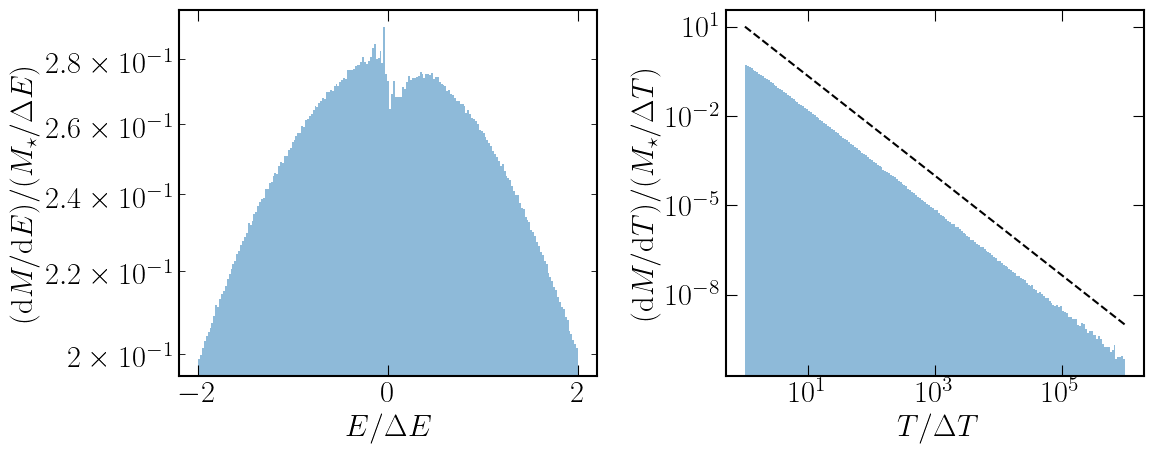

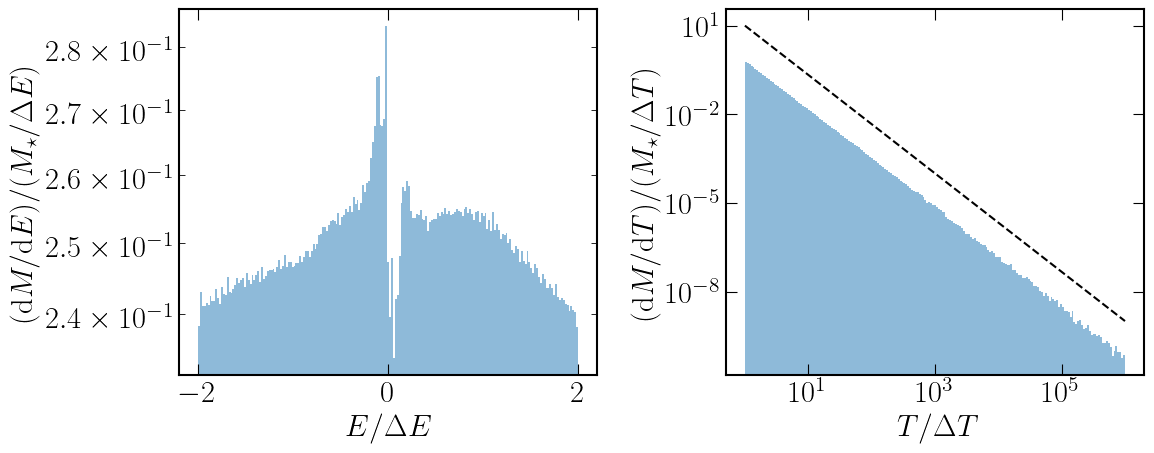

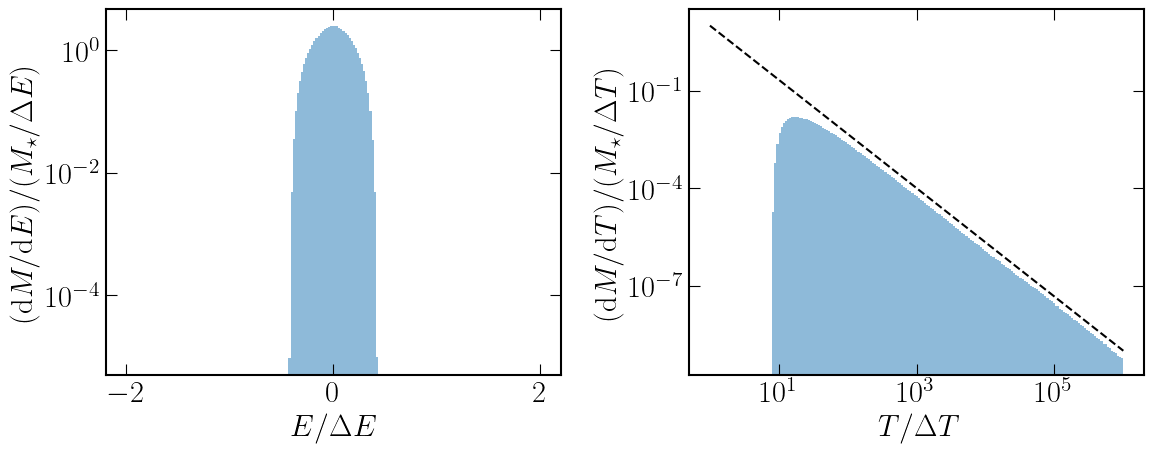

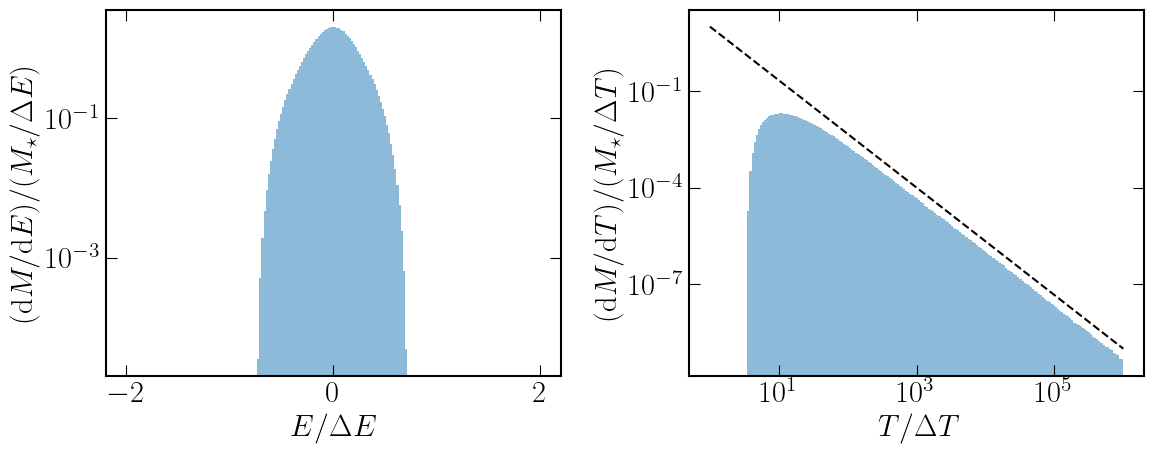

In [ ]:
energy_plots(whole_star_sample1)
energy_plots(whole_star_sample2)
energy_plots(whole_star_sample_s)
energy_plots(whole_star_sample_n)

it's not matching the newtonian case, what did I do wrong?

In [ ]:
mass = 'MAMS8Msun'
Mbh = 1e6
Rp = 6
a = 0.5
n = 1000

In [ ]:
calc = TDECalculator(mass, 'rel', Mbh, Rp, a, n)
calc_n = TDECalculator(mass, 'nwtn', Mbh, Rp, 0.0, n)
calc_s = TDECalculator(mass, 'rel', Mbh, Rp, 0.0, n)
calc2 = TDECalculator(mass, 'rel', Mbh, Rp, -a, n)

In [ ]:
whole_star_sample1 = calc.rel_whole_star_sample(N_Omega=300**2)
whole_star_sample2 = calc2.rel_whole_star_sample(N_Omega=300**2)
whole_star_sample_s = calc_s.rel_whole_star_sample(N_Omega=300**2)
whole_star_sample_n = calc_n.whole_star_sample(N_Omega=300**2)

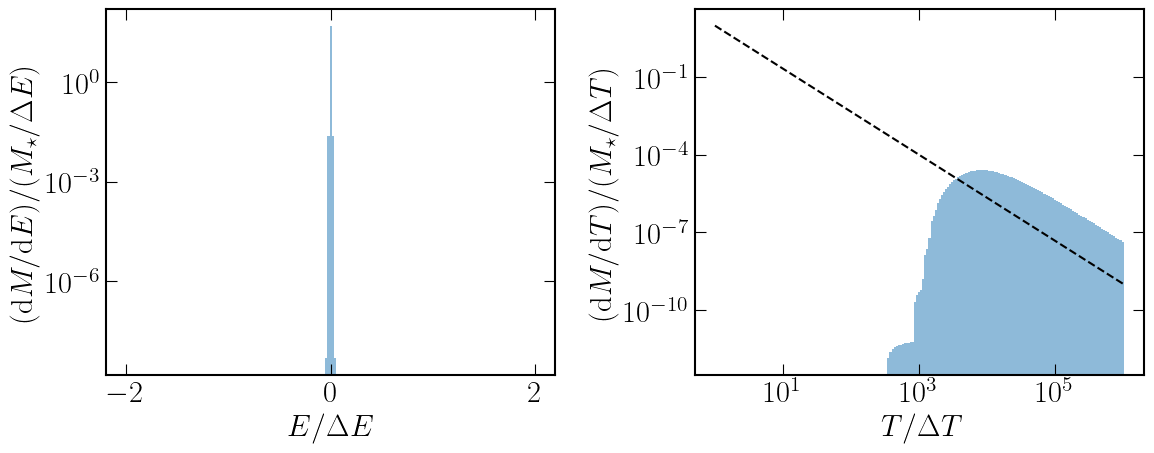

In [ ]:
energy_plots(whole_star_sample1)

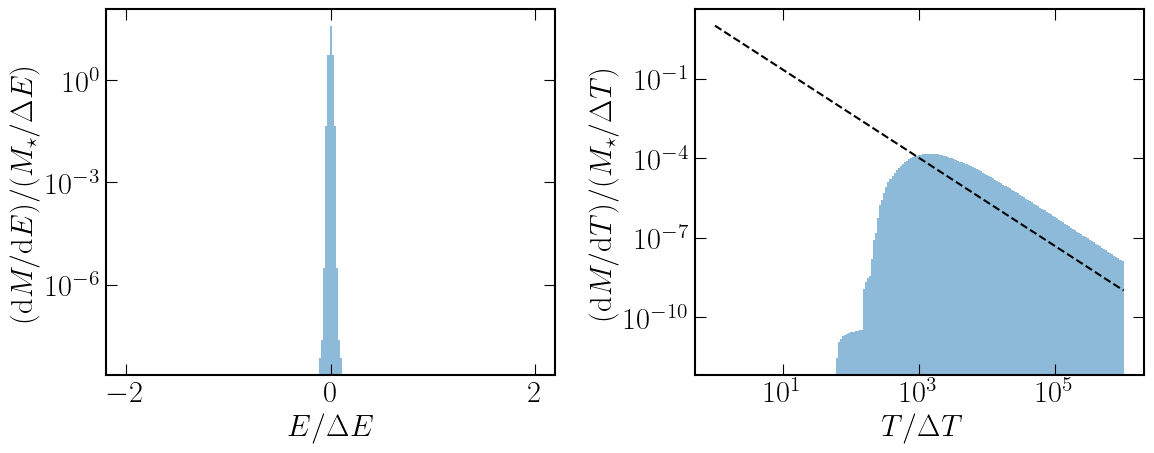

In [ ]:
energy_plots(whole_star_sample2)

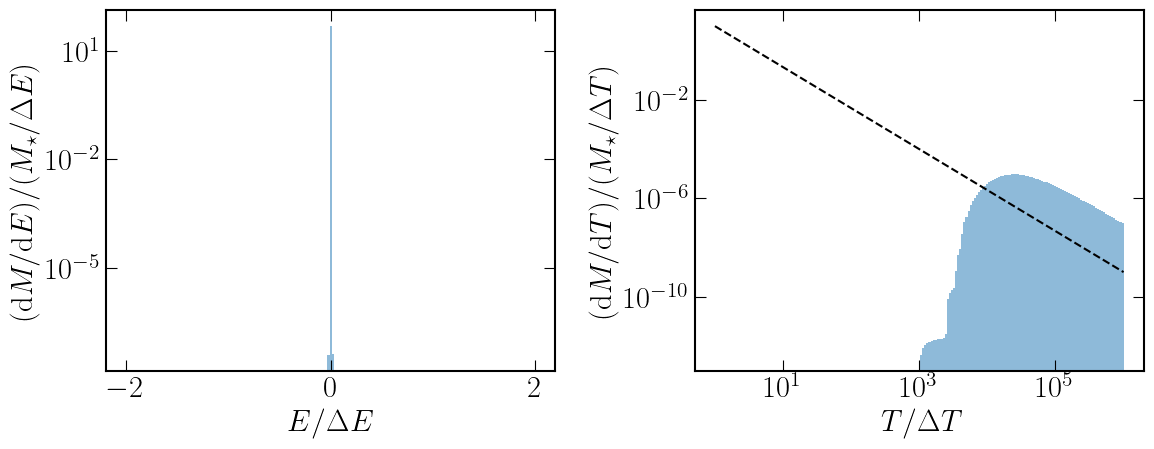

In [ ]:
energy_plots(whole_star_sample_s)

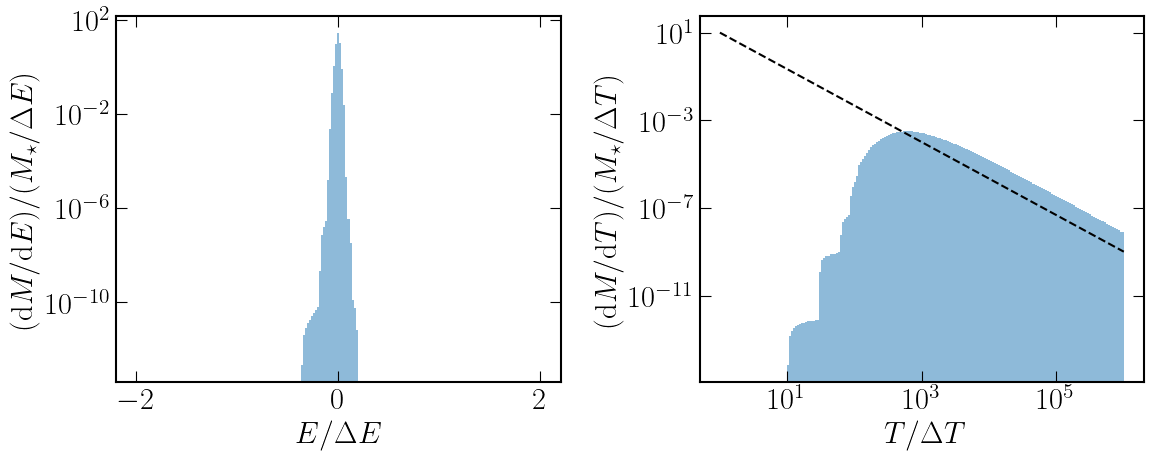

In [ ]:
energy_plots(whole_star_sample_n)

In [ ]:
mass = 'MAMS1Msun'
Mbh = 1e6
Rp = 4.9497
a = 0.5
n = 1000

In [ ]:
calc = TDECalculator(mass, 'rel', Mbh, Rp, a, n)
calc_n = TDECalculator(mass, 'nwtn', Mbh, Rp, 0.0, n)
calc_s = TDECalculator(mass, 'rel', Mbh, Rp, 0.0, n)
calc2 = TDECalculator(mass, 'rel', Mbh, Rp, -a, n)

In [ ]:
whole_star_sample1 = calc.rel_whole_star_sample(N_Omega=300**2)
whole_star_sample2 = calc2.rel_whole_star_sample(N_Omega=300**2)
whole_star_sample_s = calc_s.rel_whole_star_sample(N_Omega=300**2)
whole_star_sample_n = calc_n.whole_star_sample(N_Omega=300**2)

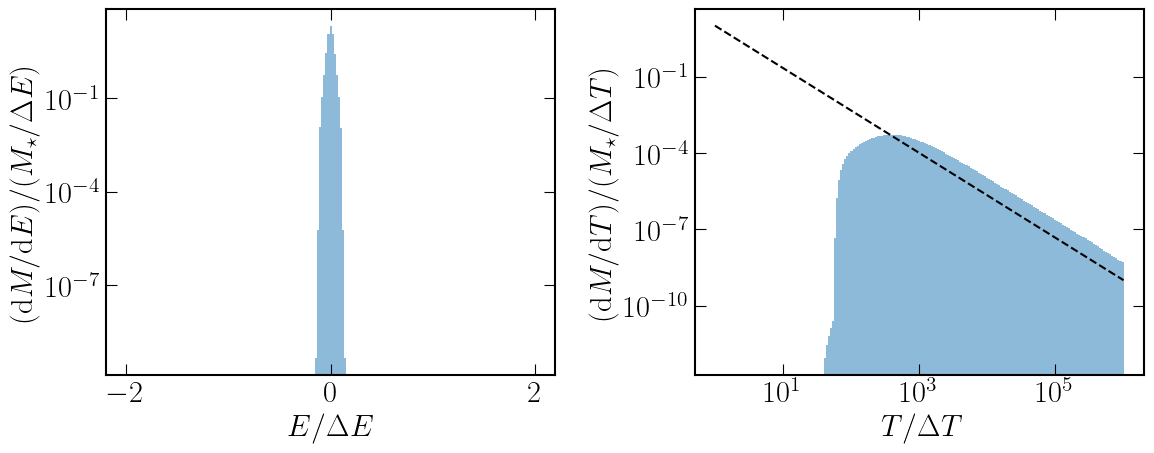

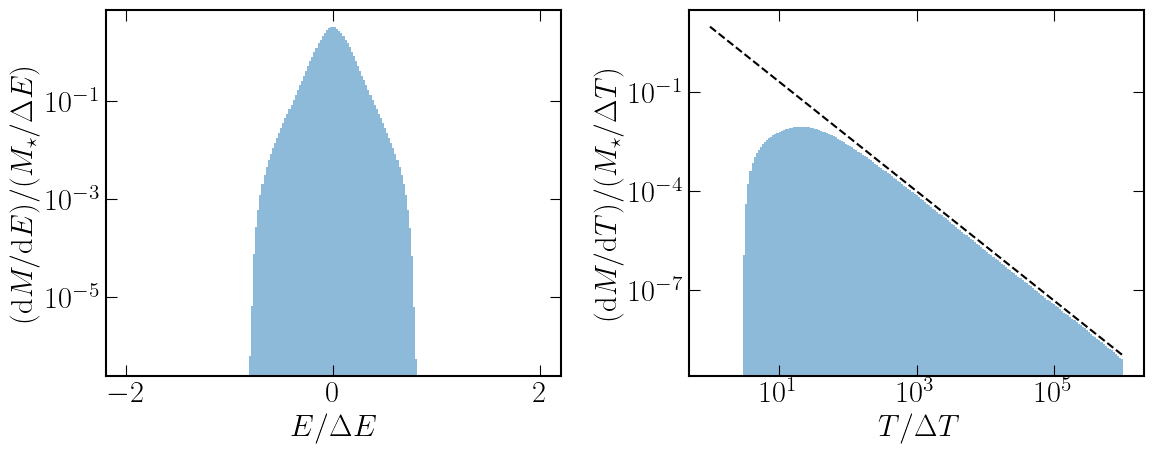

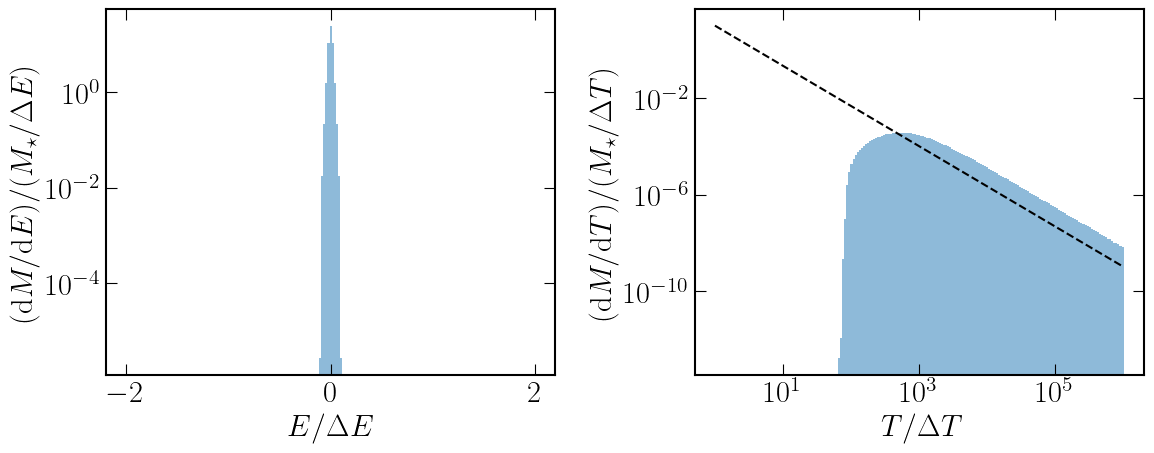

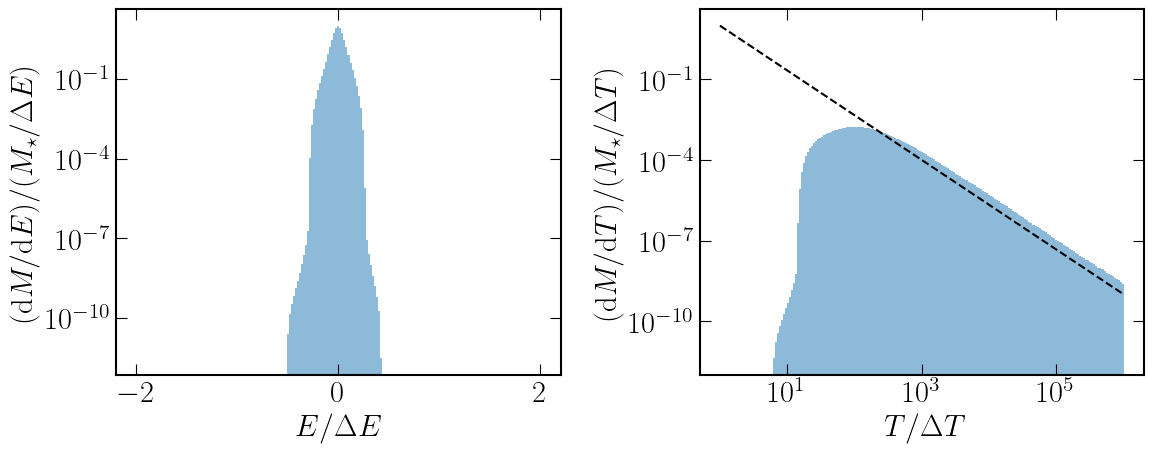

In [ ]:
energy_plots(whole_star_sample1)
energy_plots(whole_star_sample2)
energy_plots(whole_star_sample_s)
energy_plots(whole_star_sample_n)

In [ ]:
mass = 'MAMS0p7Msun'
Mbh = 1e6
Rp = 6.0
a = 0.5
n = 1000

In [ ]:
calc = TDECalculator(mass, 'rel', Mbh, Rp, a, n)
calc_n = TDECalculator(mass, 'nwtn', Mbh, Rp, 0.0, n)
calc_s = TDECalculator(mass, 'rel', Mbh, Rp, 0.0, n)
calc2 = TDECalculator(mass, 'rel', Mbh, Rp, -a, n)

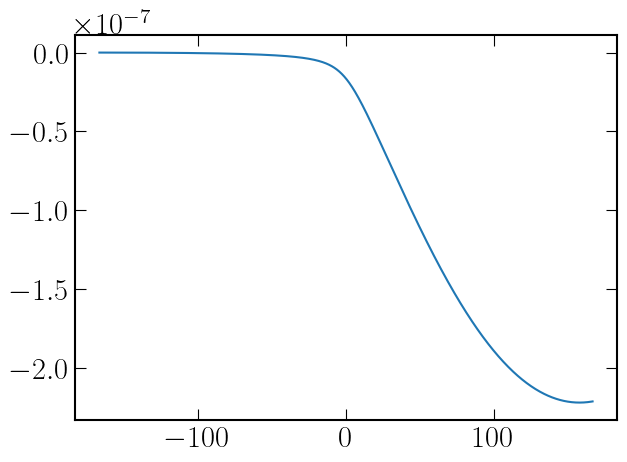

In [ ]:
plt.plot(calc.t, calc.Q_all[2,2]) #rp = 17

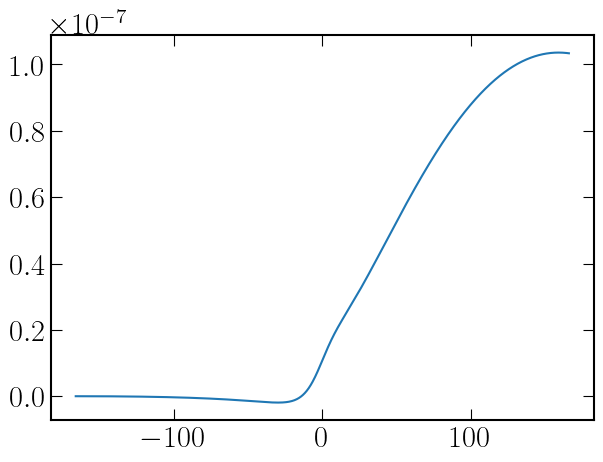

In [ ]:
plt.plot(calc.t, calc.Q_all[1,1])

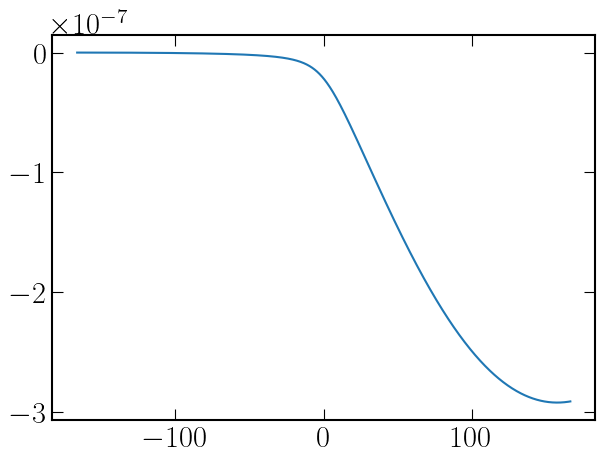

In [ ]:
plt.plot(calc_s.t, calc_s.Q_all[2,2])

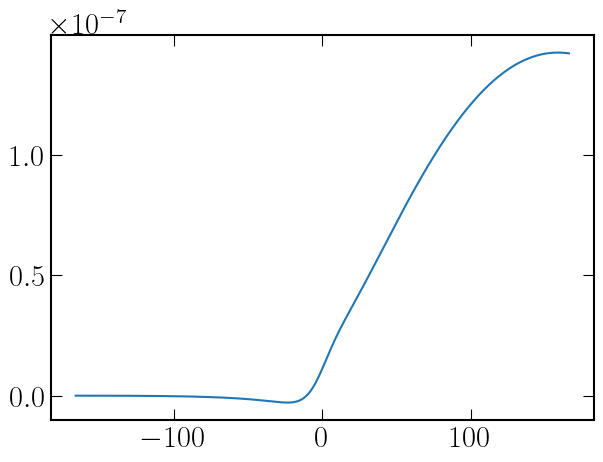

In [ ]:
plt.plot(calc_s.t, calc_s.Q_all[1,1])

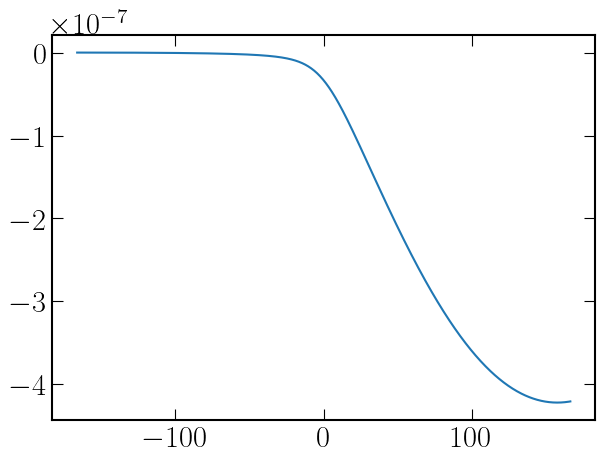

In [ ]:
plt.plot(calc2.t, calc2.Q_all[2,2])

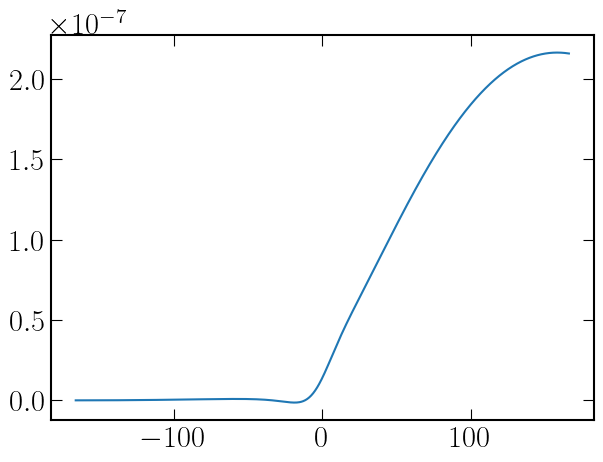

In [ ]:
plt.plot(calc2.t, calc2.Q_all[1,1])

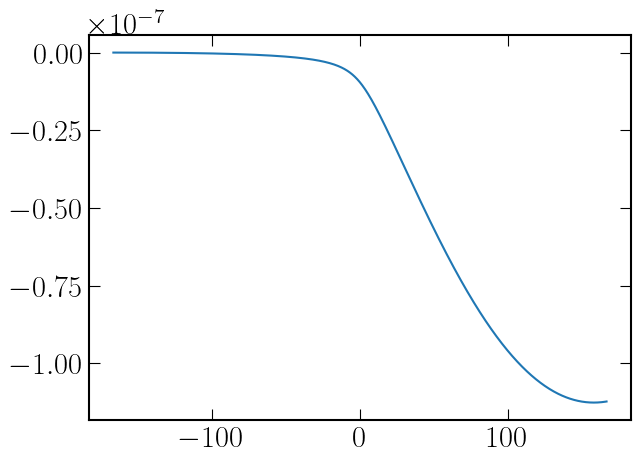

In [ ]:
plt.plot(calc_n.t, calc_n.Q_all[2,2])

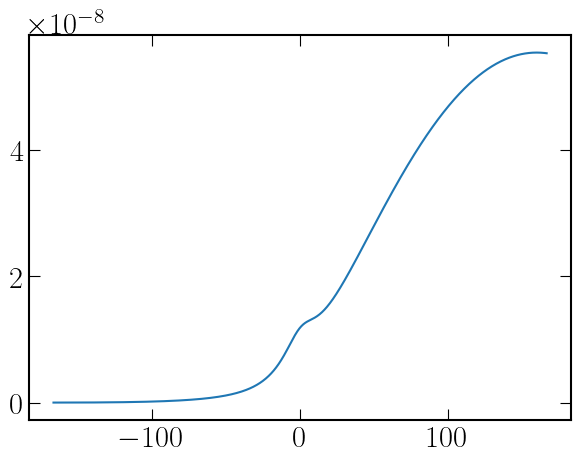

In [ ]:
plt.plot(calc_n.t, calc_n.Q_all[1,1])

In [ ]:
def quadrupole_plot(calc, label):
    time = calc.t
    i = calc.i_TDE

    qxx = np.abs(calc.Q_all[0,0]) / (calc.mass_ratio / calc.Rstar**2)
    qyy = np.abs(calc.Q_all[1,1]) / (calc.mass_ratio / calc.Rstar**2)
    qxy = np.abs(calc.Q_all[0,1]) / (calc.mass_ratio / calc.Rstar**2)
    qzz = np.abs(calc.Q_all[2,2]) / (calc.mass_ratio / calc.Rstar**2)

    comp = calc.TidalEnergy / np.abs(calc.U * (calc.mass_ratio**2 / calc.Rstar)) 

    plt.title(label)

    plt.plot(time[:i], qxx[:i], color='C0', label='$|Q_{xx}| / (M_{*} R_{*}^2)$')
    plt.plot(time[:i], qxy[:i], color='C1', label='$|Q_{xy}| / (M_{*} R_{*}^2)$')
    plt.plot(time[:i], qyy[:i], color='C2', label='$|Q_{yy}| / (M_{*} R_{*}^2)$')
    plt.plot(time[:i], qzz[:i], color='C3', label='$|Q_{zz}| / (M_{*} R_{*}^2)$')
    plt.plot(time[:i], comp[:i], color='black', label='$E_{Q} / |U_{bind}|$')

    plt.plot(time[i:], qxx[i:], color='C0', linestyle=':')
    plt.plot(time[i:], qxy[i:], color='C1', linestyle=':')
    plt.plot(time[i:], qyy[i:], color='C2', linestyle=':')
    plt.plot(time[i:], qzz[i:], color='C3', linestyle=':')
    plt.plot(time[i:], comp[i:], color='black', linestyle=':')
    plt.xlabel('$t/(GM_{BH})$')

    plt.axvline(time[i], linestyle='--', color='0.5')
    plt.axhline(calc.gamma, linestyle='--', color='0.5')
    plt.xlim(time[0], 50)
    plt.yscale('log')

    plt.legend(fontsize=10)
    plt.show()

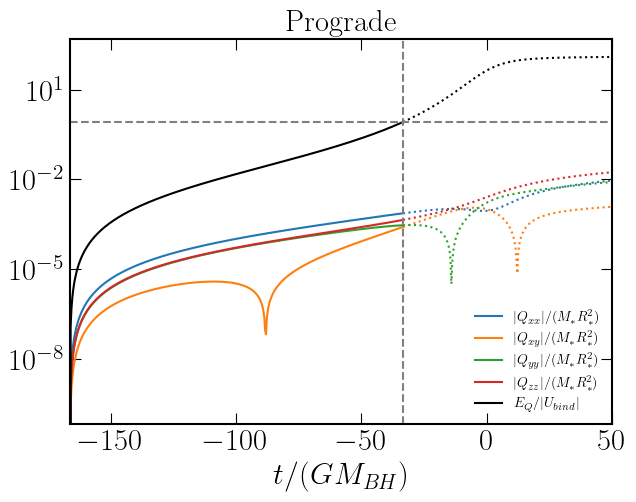

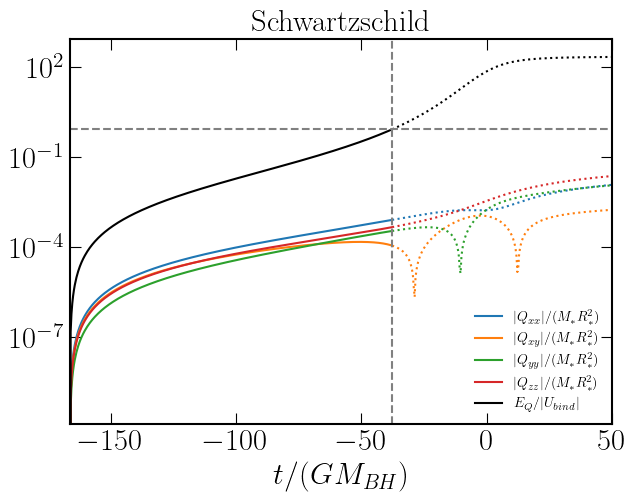

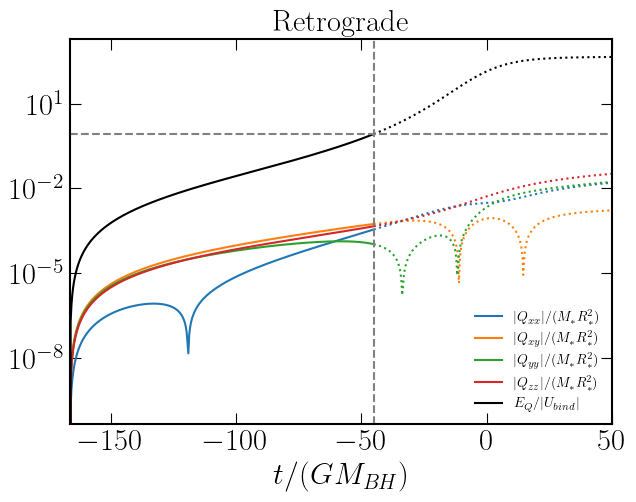

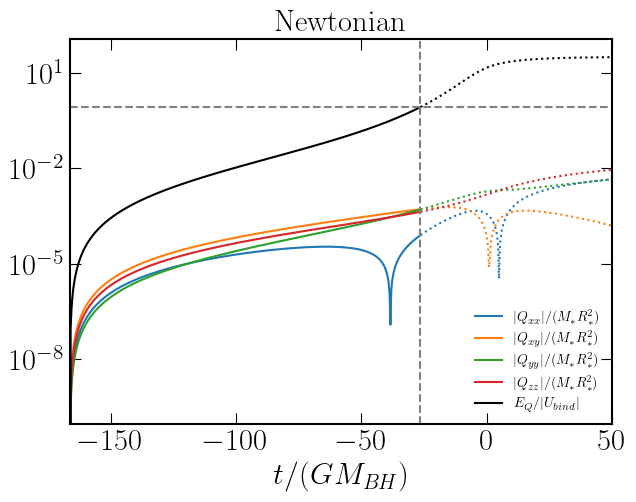

In [ ]:
quadrupole_plot(calc, 'Prograde')
quadrupole_plot(calc_s, 'Schwartzschild')
quadrupole_plot(calc2, 'Retrograde')
quadrupole_plot(calc_n, 'Newtonian')

In [ ]:
import os

def get_folder_names(directory_path):
    """
    Returns a list of folder names within the specified directory.
    """
    folder_names = []
    for item in os.listdir(directory_path):
        item_path = os.path.join(directory_path, item)
        if os.path.isdir(item_path):
            folder_names.append(item)
    return folder_names

masses = np.sort(get_folder_names('star-files')).tolist()

In [ ]:
import re

def parse_numbers(strings):
    numbers = []
    pattern = re.compile(r'-?\d+(?:p\d+|\.\d+)?')

    for s in strings:
        matches = pattern.findall(s)
        for match in matches:
            # Replace 'p' with '.' to convert formats like 0p15 to 0.15
            number_str = match.replace('p', '.')
            try:
                numbers.append(float(number_str))
            except ValueError:
                pass  # Skip malformed numbers

    return np.array(numbers)

In [ ]:
masses

['MAMS0p15Msun',
 'MAMS0p3Msun',
 'MAMS0p5Msun',
 'MAMS0p7Msun',
 'MAMS0p85Msun',
 'MAMS1Msun',
 'MAMS1p1Msun',
 'MAMS1p2Msun',
 'MAMS1p4Msun',
 'MAMS1p6Msun',
 'MAMS1p8Msun',
 'MAMS2Msun',
 'MAMS2p5Msun',
 'MAMS3Msun',
 'MAMS3p5Msun',
 'MAMS4Msun',
 'MAMS4p5Msun',
 'MAMS5Msun',
 'MAMS5p5Msun',
 'MAMS6Msun',
 'MAMS6p5Msun',
 'MAMS7Msun',
 'MAMS7p5Msun',
 'MAMS8Msun']

In [ ]:
def tidal_energy_g(self):
        """
        Integrate the work done by the tidal field to find the cumulative
        tidal energy deposited in the star over time.
        """
        t, N = self.t, self.N

        # Instantaneous power: Q_ab * (dE_ab/dt), summed over tensor indices
        power = (
            self.Q_g[0,0] * self.dEdt[0,0]
          + self.Q_g[1,1] * self.dEdt[1,1]
          + self.Q_g[2,2] * self.dEdt[2,2]
          + 2 * self.Q_g[0,1] * self.dEdt[0,1]
        )

        # 1) Cumulative integral of power: ∫_0^t power dt'
        TE_cumulative = 0.5 * cp.integrate.cumulative_trapezoid(power, t, initial=0)

        # 2) Subtract instantaneous potential term 0.5 Q_ab E_ab
        instant_term = 0.5 * (
            self.Q_g[0,0] * self.E[0,0]
          + self.Q_g[1,1] * self.E[1,1]
          + self.Q_g[2,2] * self.E[2,2]
          + 2 * self.Q_g[0,1] * self.E[0,1]
        )

        # Store net tidal energy
        return TE_cumulative - instant_term

def tidal_energy_f(self):
        """
        Integrate the work done by the tidal field to find the cumulative
        tidal energy deposited in the star over time.
        """
        t, N = self.t, self.N

        # Instantaneous power: Q_ab * (dE_ab/dt), summed over tensor indices
        power = (
            self.Q_f[0,0] * self.dEdt[0,0]
          + self.Q_f[1,1] * self.dEdt[1,1]
          + self.Q_f[2,2] * self.dEdt[2,2]
          + 2 * self.Q_f[0,1] * self.dEdt[0,1]
        )

        # 1) Cumulative integral of power: ∫_0^t power dt'
        TE_cumulative = 0.5 * cp.integrate.cumulative_trapezoid(power, t, initial=0)

        # 2) Subtract instantaneous potential term 0.5 Q_ab E_ab
        instant_term = 0.5 * (
            self.Q_f[0,0] * self.E[0,0]
          + self.Q_f[1,1] * self.E[1,1]
          + self.Q_f[2,2] * self.E[2,2]
          + 2 * self.Q_f[0,1] * self.E[0,1]
        )

        # Store net tidal energy
        return TE_cumulative - instant_term

def tidal_energy_p(self):
        """
        Integrate the work done by the tidal field to find the cumulative
        tidal energy deposited in the star over time.
        """
        t, N = self.t, self.N

        # Instantaneous power: Q_ab * (dE_ab/dt), summed over tensor indices
        power = (
            self.Q_p[0,0] * self.dEdt[0,0]
          + self.Q_p[1,1] * self.dEdt[1,1]
          + self.Q_p[2,2] * self.dEdt[2,2]
          + 2 * self.Q_p[0,1] * self.dEdt[0,1]
        )

        # 1) Cumulative integral of power: ∫_0^t power dt'
        TE_cumulative = 0.5 * cp.integrate.cumulative_trapezoid(power, t, initial=0)

        # 2) Subtract instantaneous potential term 0.5 Q_ab E_ab
        instant_term = 0.5 * (
            self.Q_p[0,0] * self.E[0,0]
          + self.Q_p[1,1] * self.E[1,1]
          + self.Q_p[2,2] * self.E[2,2]
          + 2 * self.Q_p[0,1] * self.E[0,1]
        )

        # Store net tidal energy
        return TE_cumulative - instant_term

In [ ]:
def calculator(masses, label, Mbh, Rp, a, n):
    gs =[]
    fs =[]
    ps =[]

    for mass in masses:
        calc = TDECalculator(mass, label, Mbh, Rp, a, n)

        idx = calc.i_TDE
        Eq = calc.TidalEnergy[idx]

        g = tidal_energy_g(calc)
        f = tidal_energy_f(calc)
        p = tidal_energy_p(calc)

        gs.append(g[idx] / Eq)
        fs.append(f[idx] / Eq)
        ps.append(p[idx] / Eq)

    return gs, fs, ps

In [ ]:
def mode_plot(masses, label, Mbh, Rp, a, n):
    masses_val = parse_numbers(masses)
    g, f, p = calculator(masses, label, Mbh, Rp, a, n)

    plt.plot(masses_val, g, label='g modes')
    plt.plot(masses_val, f, label='f modes')
    plt.plot(masses_val, p, label='p modes')

    plt.legend()
    plt.ylabel('$E_{Q,i}/E_{Q}$')
    plt.xlabel('$M_{*}/M_{sun}$')

    plt.show()


In [ ]:
Mbh = 1e6
Rp = 4.99
a = 0.5
n = 1000

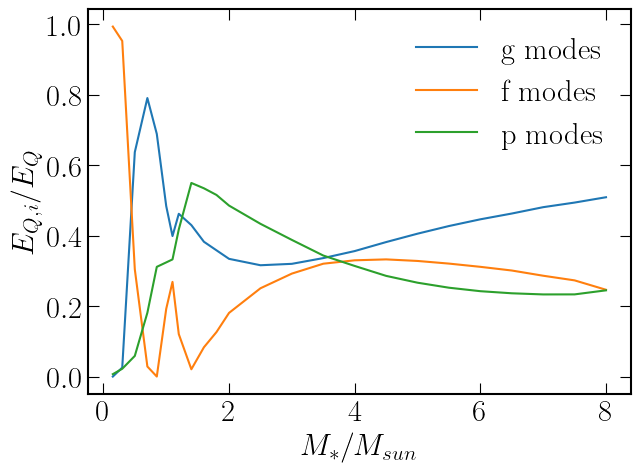

In [ ]:
Mbh = 1e6
Rp = 17
a = 1.0
n = 1000

mode_plot(masses, 'rel', Mbh, Rp, a, n)